<a href="https://colab.research.google.com/github/Hemant10HM/ANNDL-LAB_24mcs004/blob/main/ANN_LAB_2_MLP_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MLP Multivariate regression


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import make_regression
from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import trange, tqdm

#TensorFlow and Keras Libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
import torch
from torchvision import transforms
from tensorflow.keras.utils import to_categorical
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Hiding the warnings
import warnings
warnings.filterwarnings('ignore')

# Extra Libraries
import copy
import random
import time


In [4]:
# Define dataset path
dataset_path = "/content/drive/MyDrive/data/laptop_prices.csv"
df = pd.read_csv(dataset_path)

In [6]:

df.head()

,Brand,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Battery Life (hours),Weight (kg),Operating System,Price ($)
0,Apple,AMD Ryzen 3,64,512GB SSD,Nvidia GTX 1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07
1,Razer,AMD Ryzen 7,4,1TB SSD,Nvidia RTX 3080,14.0,1366x768,9.4,2.57,Linux,1355.78
2,Asus,Intel i5,32,2TB SSD,Nvidia RTX 3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07
3,Lenovo,Intel i5,4,256GB SSD,Nvidia RTX 3080,13.3,1366x768,10.5,3.10,Windows,751.17
4,Razer,Intel i3,4,256GB SSD,AMD Radeon RX 6600,16.0,3840x2160,5.7,3.38,Linux,2059.83


In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11768 entries, 0 to 11767
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 11768 non-null  object 
 1   Processor             11768 non-null  object 
 2   RAM (GB)              11768 non-null  int64  
 3   Storage               11768 non-null  object 
 4   GPU                   11768 non-null  object 
 5   Screen Size (inch)    11768 non-null  float64
 6   Resolution            11768 non-null  object 
 7   Battery Life (hours)  11768 non-null  float64
 8   Weight (kg)           11768 non-null  float64
 9   Operating System      11768 non-null  object 
 10  Price ($)             11768 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1011.4+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RAM (GB),11768.0,24.852821,21.762567,4.00,8.000,16.000,32.00,64.00
Screen Size (inch),11768.0,15.212305,1.436997,13.30,14.000,15.600,16.00,17.30
Battery Life (hours),11768.0,8.027855,2.305400,4.00,6.000,8.000,10.00,12.00
Weight (kg),11768.0,2.341117,0.667921,1.20,1.760,2.340,2.91,3.50
Price ($),11768.0,2183.571608,1316.886132,279.57,1272.045,1840.865,2698.37,10807.88


In [10]:
df.shape

(11768, 11)

In [11]:

# Checking Missing values :
df.isna().sum().sum()


np.int64(0)

In [12]:

df.duplicated().sum()


np.int64(0)

In [13]:
for i in df.columns:
    if df[i].dtype == 'O':
        le = LabelEncoder()
        df[i] = le.fit_transform(df[i])

In [16]:


# Train - Test Split :
X = df.drop('Price ($)',axis=1)
y = df['Price ($)']
X_train, X_test, y_train, y_test = train_test_split(X ,y ,test_size=0.3,random_state=42)
print("X_Train Shape : ",X_train.shape)
print("X_Test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)






X_Train Shape :  (8237, 10)
X_Test Shape :  (3531, 10)
y_train Shape :  (8237,)
y_test Shape :  (3531,)


In [19]:
# Creating an MLP model :
# Keras Model ->
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(62, activation='relu', input_dim=10))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))


In [20]:
model.compile(loss='mse', optimizer='adam', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=250)


Epoch 1/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3677121.0000 - mae: 1452.2603
Epoch 2/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 882992.4375 - mae: 674.6953
Epoch 3/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 773493.2500 - mae: 613.8322
Epoch 4/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 675582.1875 - mae: 575.9414
Epoch 5/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 681061.4375 - mae: 574.0892
Epoch 6/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 656246.1875 - mae: 575.7648
Epoch 7/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 632633.6250 - mae: 565.1524
Epoch 8/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 619257.6875 - mae: 559.1486
Epoch 9/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 641803.0625 - mae: 566.0002
Epoch 10/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 607249.1875 - mae: 556.0939
Epoch 11/250
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 652023.0000 - mae: 570.0817
Epoch 12/250
258/

In [21]:

y_pred = model.predict(X_test)


111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [22]:

# Now for the regression we will calculate the R2_Score and MSE Score :
print("R2_Score : ",r2_score(y_test,y_pred))
print("RMSE Score : ",mean_squared_error(y_test,y_pred)**0.5)


R2_Score :  0.9504082736299424
RMSE Score :  298.64097756707787


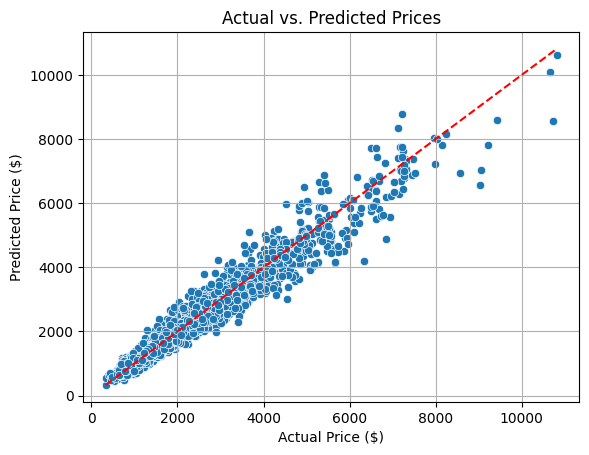

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten arrays if needed
y_test_flat = y_test.values.flatten() if hasattr(y_test, "values") else y_test.flatten()
y_pred_flat = y_pred.flatten()

# Scatter plot: Actual vs Predicted
sns.scatterplot(x=y_test_flat, y=y_pred_flat)
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'r--')  # ideal line
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted Prices")
plt.grid(True)
plt.show()
